/var/folders/hm/7tgrvf1s2cs82jf4cs2yjs400000gn/T/ipykernel_84063/247432372.py:63: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(list(tickers), start=start, end=end, progress=False)["Close"]


Loaded 4267 trading days (2010-01-04 to 2026-05-23), 7 currency pairs.

Full sample  -  gross of costs
------------------------------
  Annual return            0.0%
  Annual volatility        6.2%
  Sharpe ratio             0.00
  Sortino ratio            0.00
  Max drawdown           -16.4%
  Calmar ratio             0.00
  Hit rate                50.3%

Full sample  -  net of costs
----------------------------
  Annual return           -0.4%
  Annual volatility        6.2%
  Sharpe ratio            -0.06
  Sortino ratio           -0.09
  Max drawdown           -20.1%
  Calmar ratio            -0.02
  Hit rate                49.8%

  Average daily turnover: 0.16x notional

In-sample  (before 2019-01-01)  -  net
--------------------------------------
  Annual return            0.9%
  Annual volatility        6.1%
  Sharpe ratio             0.15
  Sortino ratio            0.21
  Max drawdown           -11.0%
  Calmar ratio             0.08
  Hit rate                51.0%

Out-of-sample

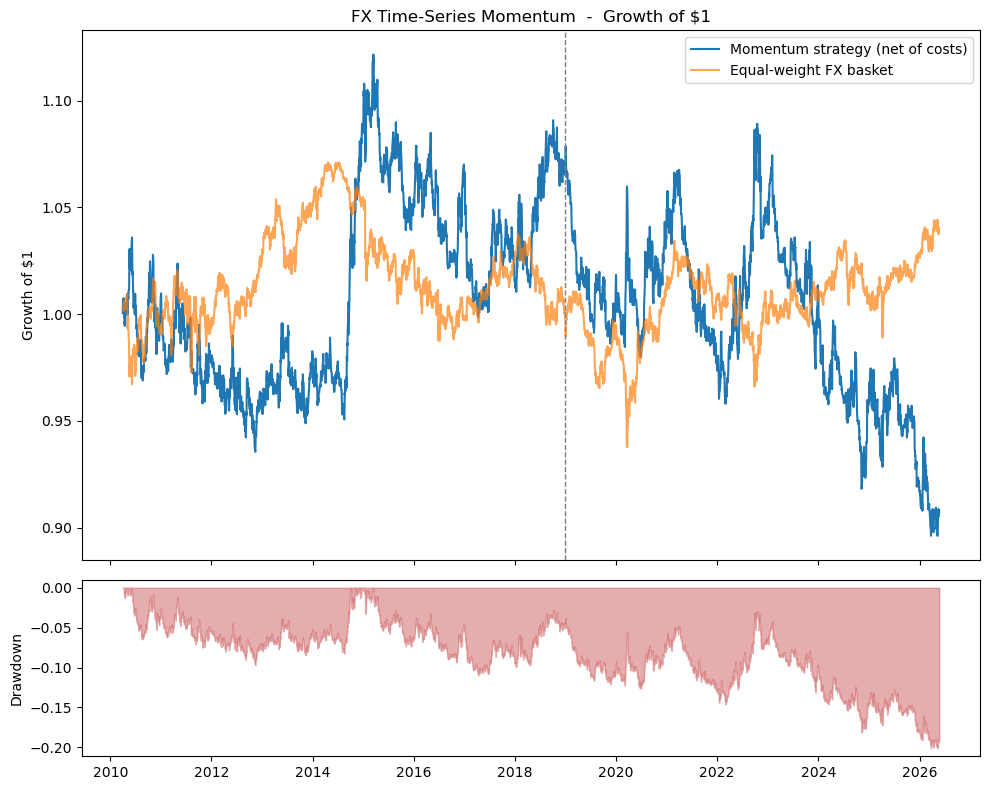

In [1]:
"""
FX Time-Series Momentum Strategy
================================
A systematic momentum strategy across a basket of G10 currency pairs.

This is built as a research backtest, not a demo. The design choices that
matter:

  * Real market data (Yahoo Finance), never simulated random walks.
  * No look-ahead: signals are lagged one day before being traded, so the
    return earned on day t uses the position decided with data up to day t-1.
  * Volatility targeting, so every pair contributes comparable risk.
  * Explicit transaction costs charged on every change in position.
  * An in-sample / out-of-sample split and a lookback parameter sweep, to
    show the result is not curve-fitted.

Author: Suzy Tang
Run:    pip install yfinance pandas numpy matplotlib
        python fx_momentum_strategy.py
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
TICKERS = {
    "EURUSD=X": "EUR/USD",
    "GBPUSD=X": "GBP/USD",
    "AUDUSD=X": "AUD/USD",
    "NZDUSD=X": "NZD/USD",
    "USDJPY=X": "USD/JPY",
    "USDCAD=X": "USD/CAD",
    "USDCHF=X": "USD/CHF",
}

START_DATE     = "2010-01-01"
END_DATE       = None          # None -> today
LOOKBACK_DAYS  = 63            # ~3 months of trading days for the momentum signal
VOL_WINDOW     = 63            # window for the realised-volatility estimate
TARGET_VOL     = 0.10          # annualised volatility target, per pair
MAX_LEVERAGE   = 2.0           # cap on the per-pair scalar from vol targeting
COST_BPS       = 1.0           # transaction cost, basis points of notional traded
TRADING_DAYS   = 252
OOS_SPLIT_DATE = "2019-01-01"  # before = in-sample, on/after = out-of-sample


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
def load_fx_data(tickers: dict, start: str, end) -> pd.DataFrame:
    """Download daily close prices; return one clean column per currency pair."""
    try:
        import yfinance as yf
    except ImportError:
        raise SystemExit("Missing dependency. Run:  pip install yfinance")

    raw = yf.download(list(tickers), start=start, end=end, progress=False)["Close"]
    prices = raw.rename(columns=tickers).ffill().dropna()
    return prices


# ---------------------------------------------------------------------------
# Signal and position sizing
# ---------------------------------------------------------------------------
def momentum_signal(prices: pd.DataFrame, lookback: int) -> pd.DataFrame:
    """+1 when the trailing return is positive (uptrend), -1 otherwise."""
    trailing_return = prices / prices.shift(lookback) - 1
    return np.sign(trailing_return)


def vol_scaled_weights(signal: pd.DataFrame, returns: pd.DataFrame,
                       target_vol: float, vol_window: int,
                       max_leverage: float) -> pd.DataFrame:
    """Scale each pair by recent realised volatility, then equal-risk budget."""
    realised_vol = returns.rolling(vol_window).std() * np.sqrt(TRADING_DAYS)
    scalar = (target_vol / realised_vol).clip(upper=max_leverage)
    weights = signal * scalar
    return weights / signal.shape[1]          # split risk across the pairs


# ---------------------------------------------------------------------------
# Backtest
# ---------------------------------------------------------------------------
def backtest(weights: pd.DataFrame, returns: pd.DataFrame, cost_bps: float):
    """Return gross and net daily strategy returns. Weights are lagged 1 day."""
    held = weights.shift(1).dropna()                  # trade on yesterday's signal
    rets = returns.loc[held.index]
    gross = (held * rets).sum(axis=1)
    turnover = held.diff().abs().sum(axis=1)          # notional traded each day
    net = gross - turnover.fillna(0) * (cost_bps / 1e4)
    return gross, net, turnover


def performance(returns: pd.Series) -> dict:
    """Standard performance statistics for a daily return series."""
    ann_return = returns.mean() * TRADING_DAYS
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    downside = returns[returns < 0].std() * np.sqrt(TRADING_DAYS)
    curve = (1 + returns).cumprod()
    drawdown = (curve / curve.cummax() - 1).min()
    return {
        "Annual return": ann_return,
        "Annual volatility": ann_vol,
        "Sharpe ratio": ann_return / ann_vol if ann_vol else np.nan,
        "Sortino ratio": ann_return / downside if downside else np.nan,
        "Max drawdown": drawdown,
        "Calmar ratio": ann_return / abs(drawdown) if drawdown else np.nan,
        "Hit rate": (returns > 0).mean(),
    }


def print_metrics(title: str, metrics: dict) -> None:
    print(f"\n{title}")
    print("-" * len(title))
    pct = ("return", "volatility", "drawdown", "rate")
    for name, value in metrics.items():
        if any(k in name.lower() for k in pct):
            print(f"  {name:<20}{value:>9.1%}")
        else:
            print(f"  {name:<20}{value:>9.2f}")


# ---------------------------------------------------------------------------
# Robustness: lookback parameter sweep
# ---------------------------------------------------------------------------
def lookback_sweep(prices: pd.DataFrame, returns: pd.DataFrame,
                   lookbacks: list) -> pd.DataFrame:
    rows = []
    for lb in lookbacks:
        signal = momentum_signal(prices, lb)
        weights = vol_scaled_weights(signal, returns, TARGET_VOL,
                                     VOL_WINDOW, MAX_LEVERAGE)
        _, net, _ = backtest(weights, returns, COST_BPS)
        rows.append({"Lookback (days)": lb, **performance(net)})
    return pd.DataFrame(rows).set_index("Lookback (days)")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main() -> None:
    prices = load_fx_data(TICKERS, START_DATE, END_DATE)
    returns = prices.pct_change().dropna()
    print(f"Loaded {len(returns)} trading days "
          f"({returns.index[0].date()} to {returns.index[-1].date()}), "
          f"{returns.shape[1]} currency pairs.")

    signal = momentum_signal(prices, LOOKBACK_DAYS)
    weights = vol_scaled_weights(signal, returns, TARGET_VOL,
                                 VOL_WINDOW, MAX_LEVERAGE)
    gross, net, turnover = backtest(weights, returns, COST_BPS)

    print_metrics("Full sample  -  gross of costs", performance(gross))
    print_metrics("Full sample  -  net of costs",   performance(net))
    print(f"\n  Average daily turnover: {turnover.mean():.2f}x notional")

    in_sample = net[net.index < OOS_SPLIT_DATE]
    out_sample = net[net.index >= OOS_SPLIT_DATE]
    print_metrics(f"In-sample  (before {OOS_SPLIT_DATE})  -  net",
                  performance(in_sample))
    print_metrics(f"Out-of-sample  (from {OOS_SPLIT_DATE})  -  net",
                  performance(out_sample))

    sweep = lookback_sweep(prices, returns, [21, 42, 63, 126, 252])
    print("\nLookback sensitivity (net Sharpe should be reasonably stable):")
    print(sweep[["Sharpe ratio", "Annual return", "Max drawdown"]].round(2))

    equity = (1 + net).cumprod()
    benchmark = (1 + returns.mean(axis=1).reindex(net.index)).cumprod()

    fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1]})
    ax[0].plot(equity.index, equity, label="Momentum strategy (net of costs)")
    ax[0].plot(benchmark.index, benchmark, alpha=0.7,
               label="Equal-weight FX basket")
    ax[0].axvline(pd.Timestamp(OOS_SPLIT_DATE), ls="--", c="grey", lw=1)
    ax[0].set_title("FX Time-Series Momentum  -  Growth of $1")
    ax[0].set_ylabel("Growth of $1")
    ax[0].legend()
    drawdown = equity / equity.cummax() - 1
    ax[1].fill_between(drawdown.index, drawdown, 0, color="indianred", alpha=0.5)
    ax[1].set_ylabel("Drawdown")
    fig.tight_layout()
    fig.savefig("fx_momentum_results.png", dpi=120)
    print("\nSaved equity-curve chart to fx_momentum_results.png")


if __name__ == "__main__":
    main()
